# Task1: Perform Data Cleaning, Aggregation and Filtering

In [25]:
import pandas as pd

# load titanic dataset
df = pd.read_csv('./titanic.csv')

# inspect data
print(df.info())
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071  

In [26]:
# Handle missing values
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Remove duplicates
df = df.drop_duplicates()

In [27]:
# filter data: Passengers in first class
first_class = df[df['Pclass'] == 1]
print("First class passengers: \n",first_class.head())

First class passengers: 
     PassengerId  Survived  Pclass  \
1             2         1       1   
3             4         1       1   
6             7         0       1   
11           12         1       1   
23           24         1       1   

                                                 Name     Sex   Age  SibSp  \
1   Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
3        Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
6                             McCarthy, Mr. Timothy J    male  54.0      0   
11                           Bonnell, Miss. Elizabeth  female  58.0      0   
23                       Sloper, Mr. William Thompson    male  28.0      0   

    Parch    Ticket     Fare Cabin Embarked  
1       0  PC 17599  71.2833   C85        C  
3       0    113803  53.1000  C123        S  
6       0     17463  51.8625   E46        S  
11      0    113783  26.5500  C103        S  
23      0    113788  35.5000    A6        S  


# Task2: Generate visualizations to illustrate key insights

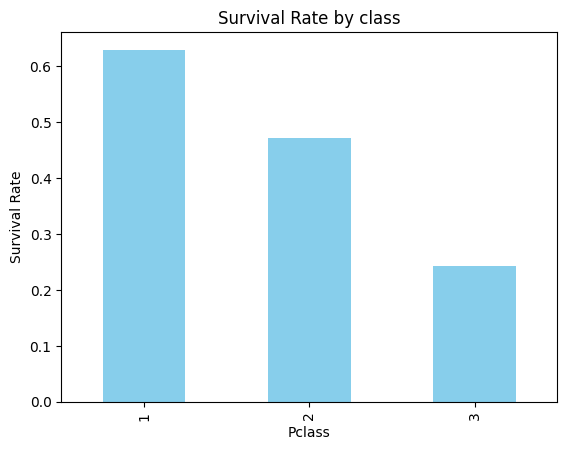

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Bar Chart: Survival rate by class
survival_by_class = df.groupby('Pclass')['Survived'].mean()
survival_by_class.plot(kind='bar',color='skyblue')
plt.title("Survival Rate by class")
plt.ylabel("Survival Rate")
plt.show()

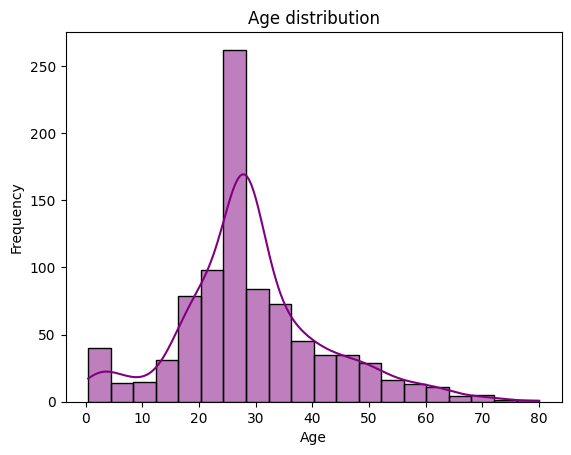

In [36]:
# Histogram: Age distribution
sns.histplot(df["Age"], kde=True, bins=20, color="purple")
plt.title("Age distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

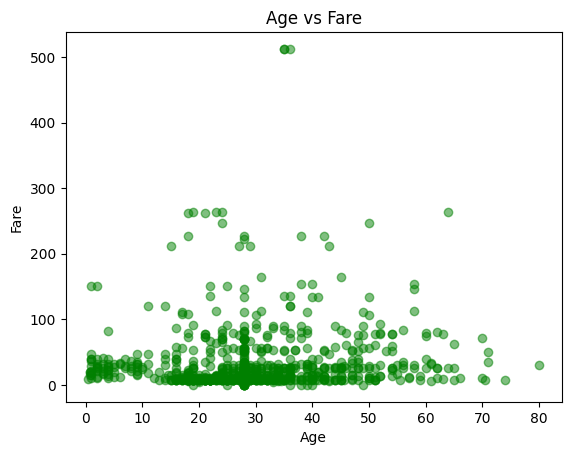

In [34]:
# Scatter plot: Age vs Fare
plt.scatter(df["Age"],df["Fare"],alpha=0.5, color="green")
plt.title("Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

# Task 3: Identify and Interpret Patterns and Anomalies

### Titanic Dataset EDA Report
1. Overview
    - Dataset contains 891 rows and 12 columns
    - Missing values handled for Age(filled with median) and Embarked(filled with mode)

2. Key Insights:
    - Survival rates are highest for first-class passengers(62%) lowest for third-class passengers(24%).
    - Majority of passengers are aged between 20-40 years
    - A positive correlation exists between fare and survival

3. Visual Insights:
    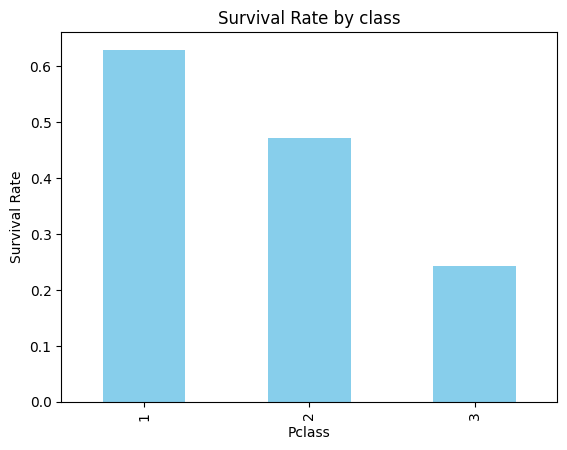


    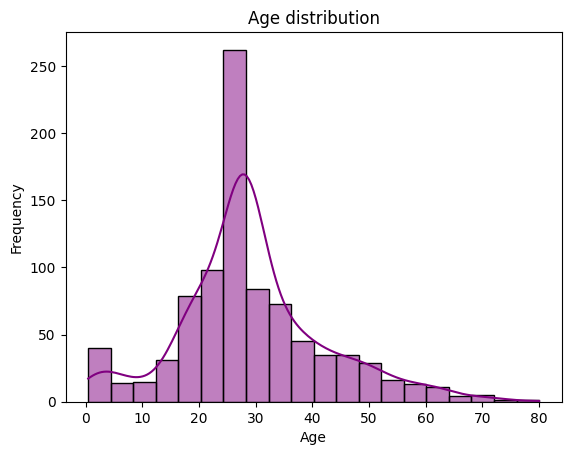

    
    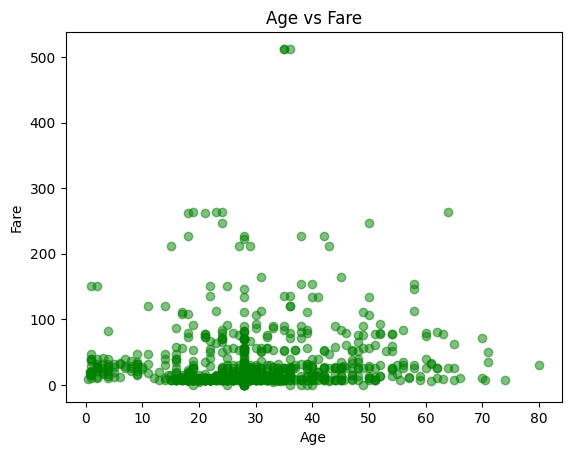

# Task 5: Create a dashboard for your findings using plotly or Dash

In [50]:
import dash
from dash import dcc, html
import plotly.express as px
import pandas as pd
from jupyter_dash import JupyterDash

# Load Titanic dataset
titanic = pd.read_csv("./titanic.csv")

# Handle missing values
titanic["Age"].fillna(titanic["Age"].median(), inplace=True)
titanic["Embarked"].fillna(titanic["Embarked"].mode()[0], inplace=True)

# Survival rates by class
survival_by_class = titanic.groupby("Pclass")["Survived"].mean().reset_index()
fig_class = px.bar(survival_by_class, x="Pclass", y="Survived",
                   labels={"Survived":"Survival Rate"},
                   title="Survival Rate by Passenger Class")

# Age distribution
fig_age = px.histogram(titanic, x="Age", nbins=30, color="Survived",
                       barmode="overlay", title="Age Distribution by Survival")

# Fare vs Survival
fig_fare = px.box(titanic, x="Survived", y="Fare",
                  labels={"Survived":"Survived (0=No, 1=Yes)"},
                  title="Fare vs Survival")

# Initialize Dash app
app = dash.Dash(__name__)

app.layout = html.Div([
    html.H1("Titanic Dataset EDA Dashboard"),
    
    html.Div([
        html.H3("Survival Rate by Class"),
        dcc.Graph(figure=fig_class)
    ]),
    
    html.Div([
        html.H3("Age Distribution"),
        dcc.Graph(figure=fig_age)
    ]),
    
    html.Div([
        html.H3("Fare vs Survival"),
        dcc.Graph(figure=fig_fare)
    ])
])

if __name__ == "__main__":
    app.run(debug=True)


C:\Users\sagar\AppData\Local\Temp\ipykernel_18112\1086196697.py:11: ChainedAssignmentError:

A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html

C:\Users\sagar\AppData\Local\Temp\ipykernel_18112\1086196697.py:12: ChainedAssignmentError:

A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method 